In [1]:
# ================================================
# Notebook 3: Handwriting Recognition
# Using PaddleOCR - Better for messy doctor prescriptions
# ================================================

print("🔤 Notebook 3: Handwriting Recognition (PaddleOCR Version)")

🔤 Notebook 3: Handwriting Recognition (PaddleOCR Version)


In [2]:
# Install and Import
# Cell 2: Install EasyOCR (Run once)
%pip install easyocr --quiet

import easyocr
import cv2
import matplotlib.pyplot as plt
import torch
from utils import preprocess_handwriting
import os

print("✅ EasyOCR installed and libraries imported")
print(f"GPU Available: {torch.cuda.is_available()}")

Note: you may need to restart the kernel to use updated packages.
✅ EasyOCR installed and libraries imported
GPU Available: True


In [3]:
# Initialize EasyOCR
# Cell 3: Initialize EasyOCR (This may download models first time ~200MB)
print("⏳ Loading EasyOCR models... (First time may take 30-60 seconds)")

reader = easyocr.Reader(
    ['en'], 
    gpu=torch.cuda.is_available(),
    recognizer=True,
    detector=True
)

print("✅ EasyOCR Reader initialized successfully!")

⏳ Loading EasyOCR models... (First time may take 30-60 seconds)
✅ EasyOCR Reader initialized successfully!


In [4]:
# Recognition Function
# Cell 4: Recognition Function using EasyOCR
import numpy as np
def recognize_text(image_path, preprocess=True):
    """
    Recognize text using EasyOCR
    """
    # Load original image for display
    if isinstance(image_path, str):
        original_cv = cv2.imread(image_path)
        display_img = original_cv.copy()
    else:
        display_img = cv2.cvtColor(np.array(image_path), cv2.COLOR_RGB2BGR)
        original_cv = display_img.copy()
    
    # Preprocessing (strongly recommended for prescriptions)
    if preprocess:
        print("🛠️ Applying preprocessing...")
        processed_pil, processed_cv = preprocess_handwriting(image_path, show_steps=False)
        img_to_use = processed_cv
    else:
        img_to_use = original_cv
    
    # Show original image
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis('off')
    plt.show()
    
    print("🤖 Running EasyOCR...")
    
    # Run EasyOCR
    result = reader.readtext(img_to_use, detail=1, paragraph=False)
    
    recognized_lines = []
    for detection in result:
        text = detection[1]
        confidence = detection[2]
        recognized_lines.append(text)
        print(f"→ {text:<60} (Conf: {confidence:.3f})")
    
    final_text = "\n".join(recognized_lines)
    
    print("\n" + "="*90)
    print("✅ FINAL RECOGNIZED TEXT:")
    print("="*90)
    print(final_text)
    print("="*90)
    
    return final_text

🛠️ Applying preprocessing...


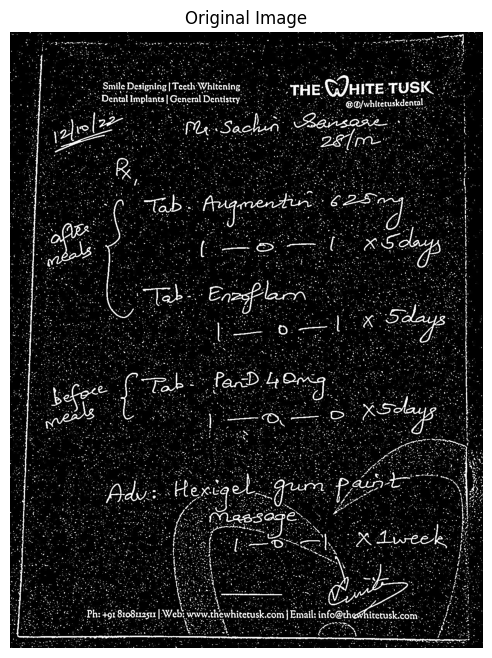

🤖 Running EasyOCR...
→ 08                                                           (Conf: 0.955)
→ FEX                                                          (Conf: 0.165)
→ encni                                                        (Conf: 0.255)
→ hizsiskacnd                                                  (Conf: 0.030)
→ Q                                                            (Conf: 0.677)
→ 8                                                            (Conf: 0.516)
→ 30                                                           (Conf: 0.410)
→ 8                                                            (Conf: 0.171)
→ 8                                                            (Conf: 0.224)
→ '8i883554 cb                                                 (Conf: 0.054)
→ thc                                                          (Conf: 0.858)
→ tctusk com                                                   (Conf: 0.443)
→ Efail                                                

In [5]:
# Test on single image
# Cell 5: Test on One Image
# =========================
test_image_path = r"C:\Users\Avilasha\Desktop\handwriting-ocr\processed_images\processed_1_3xUyINxRtDf2qowd-kkGQA.jpg"   # ← CHANGE THIS PATH

recognized_text = recognize_text(test_image_path, preprocess=True)

# Save result
with open("recognized_text.txt", "w", encoding="utf-8") as f:
    f.write(recognized_text)

print("\n✅ Text saved to recognized_text.txt")